# Credit Card Fraud Detection Using Machine Learning

## Objective

The goal of this project is to detect **fraudulent credit card transactions** using machine learning.

Most transactions are genuine, but a few are fraud. We will train a model to automatically tell them apart.

**Dataset:** Kaggle Credit Card Fraud Detection Dataset
- Columns: `Time`, `V1` to `V28` (anonymized), `Amount`, and `Class`
- `Class = 0` → Normal transaction
- `Class = 1` → Fraudulent transaction


## Step 1: Download the Dataset

We use the `kagglehub` library to download the dataset directly from Kaggle.

> **First time setup:** You will need a free Kaggle account. When prompted, enter your Kaggle username and API key.
> You can find your API key at: https://www.kaggle.com/settings → "Create New Token"


In [48]:
# Install kagglehub (only needed once)
!pip install kagglehub -q


zsh:1: command not found: pip


In [49]:
# Download the dataset from Kaggle
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

# Copy creditcard.csv to the current folder (if not already there)
src = os.path.join(path, "creditcard.csv")
dst = "creditcard.csv"
if not os.path.exists(dst):
    shutil.copy(src, dst)
    print("Copied creditcard.csv to current folder.")
else:
    print("creditcard.csv already exists in current folder.")


100%|██████████| 66.0M/66.0M [00:06<00:00, 10.7MB/s]

Extracting files...


Dataset downloaded to: /Users/admin/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
Copied creditcard.csv to current folder.


## Step 2: Import Libraries


In [50]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 3: Load the Dataset


In [51]:
# Load the CSV file
df = pd.read_csv('creditcard.csv')
print("Dataset loaded. Total rows:", len(df))


Dataset loaded. Total rows: 284807


## Step 4: Basic Data Analysis

Let's understand the dataset before building any model.


In [52]:
# Check the shape (rows, columns)
print("Shape:", df.shape)


Shape: (284807, 31)


In [53]:
# Display first 5 rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [54]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())


Missing values: 0


In [55]:
# Check data types
df.dtypes


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [56]:
# Count fraud vs normal transactions
print(df['Class'].value_counts())
print()
print("Fraud percentage:", round(df['Class'].mean() * 100, 2), "%")


Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17 %


## Step 5: Exploratory Data Analysis (EDA)

Let's visualize the data using simple graphs.


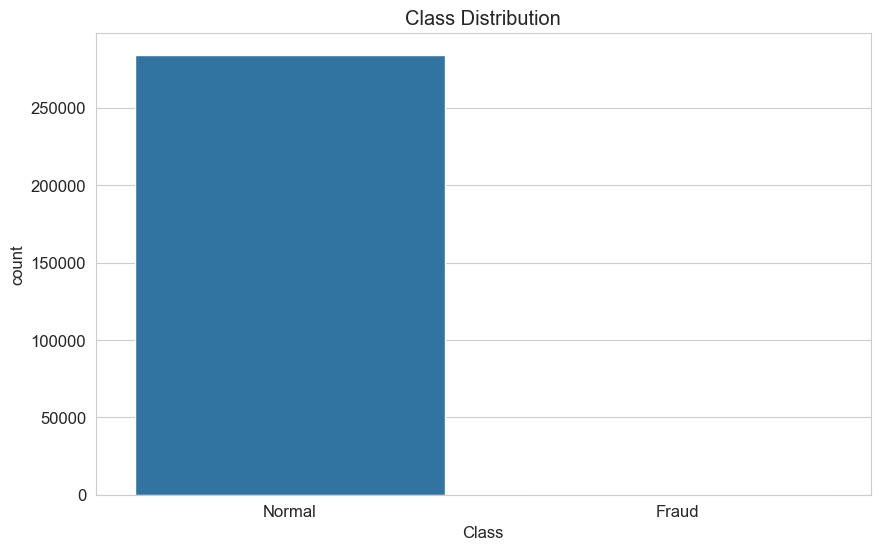

In [57]:
# Plot 1: Class distribution (Fraud vs Normal)
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()


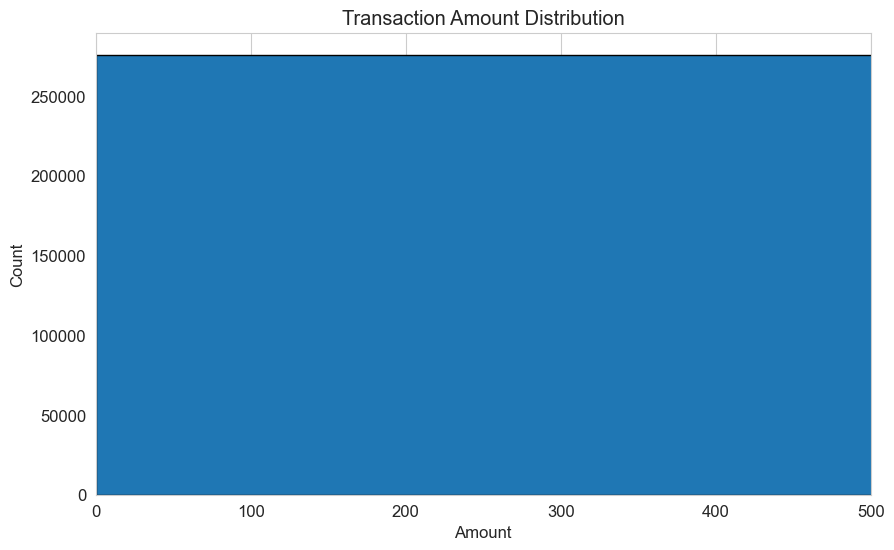

In [58]:
# Plot 2: Transaction amount distribution
plt.hist(df['Amount'], bins=50, edgecolor='black')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.xlim(0, 500)  # Zoom in for better view
plt.show()


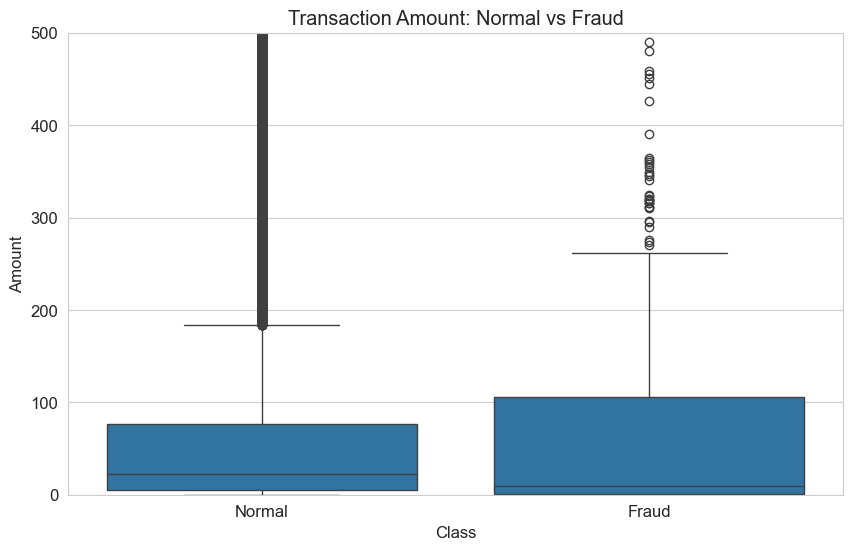

In [59]:
# Plot 3: Compare fraud vs normal amounts using box plot
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount: Normal vs Fraud')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.ylim(0, 500)
plt.show()


## Step 6: Understanding Class Imbalance

Our dataset has about **99.8% normal** and only **0.2% fraud** transactions. This is called **class imbalance**.

**Why is this a problem?**
- If a model always predicts "Normal", it will be 99.8% accurate — but it catches zero frauds!
- So accuracy alone can be misleading.
- We need other metrics like **Precision**, **Recall**, and **F1-Score** to properly evaluate the model.


## Step 7: Data Preprocessing

We need to prepare the data before training:
1. Scale the `Amount` column (so all features are on a similar range)
2. Drop the `Time` column (not useful)
3. Split into training (80%) and testing (20%) sets


In [60]:
# Scale the Amount column
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Drop the Time column
df = df.drop('Time', axis=1)

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (284807, 29)
Target shape: (284807,)


In [61]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Testing set:", X_test.shape[0], "rows")


Training set: 227845 rows
Testing set: 56962 rows


## Step 8: Train Machine Learning Models

We will train two simple models:
1. **Logistic Regression** — A simple model that predicts probabilities
2. **Decision Tree** — A model that makes decisions like a flowchart


In [62]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression trained.")


Logistic Regression trained.


In [63]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Decision Tree trained.")


Decision Tree trained.


## Step 9: Model Evaluation

We evaluate using:
- **Accuracy** — How many predictions were correct overall
- **Precision** — When model says fraud, how often is it correct
- **Recall** — Out of all real frauds, how many did the model catch
- **F1-Score** — A balance between precision and recall
- **Confusion Matrix** — Shows correct/incorrect predictions in a table


In [64]:
# Evaluate Logistic Regression
print("=== Logistic Regression ===")
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall   :", round(recall_score(y_test, lr_pred), 4))
print("F1-Score :", round(f1_score(y_test, lr_pred), 4))
print()
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Fraud']))


=== Logistic Regression ===
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1-Score : 0.7241

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [65]:
# Evaluate Decision Tree
print("=== Decision Tree ===")
print("Accuracy :", round(accuracy_score(y_test, dt_pred), 4))
print("Precision:", round(precision_score(y_test, dt_pred), 4))
print("Recall   :", round(recall_score(y_test, dt_pred), 4))
print("F1-Score :", round(f1_score(y_test, dt_pred), 4))
print()
print(classification_report(y_test, dt_pred, target_names=['Normal', 'Fraud']))


=== Decision Tree ===
Accuracy : 0.9995
Precision: 0.8953
Recall   : 0.7857
F1-Score : 0.837

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.90      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



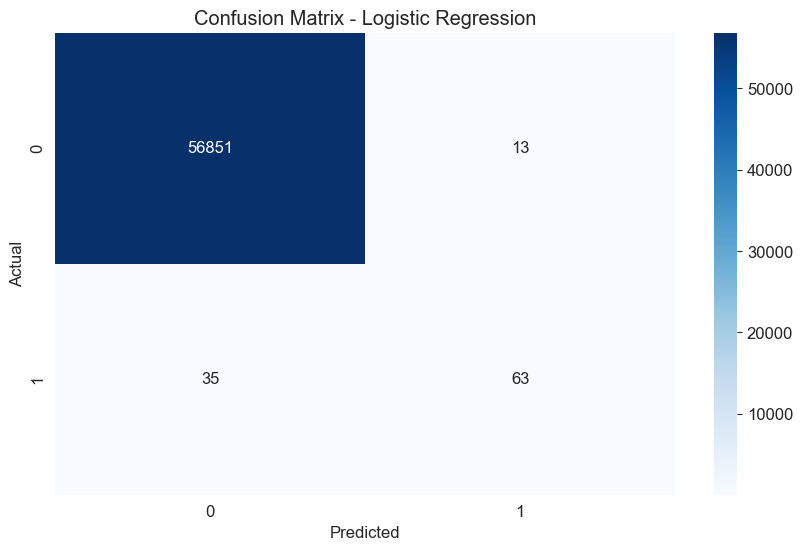

In [66]:
# Confusion Matrix - Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


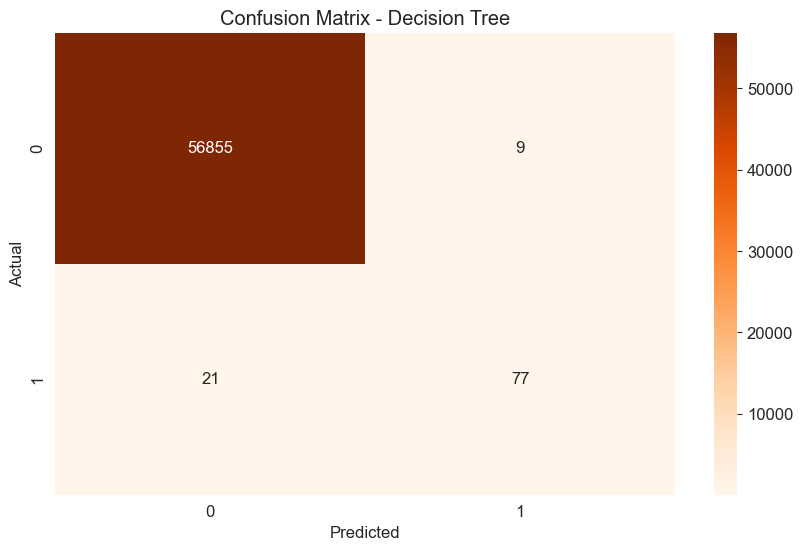

In [67]:
# Confusion Matrix - Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
